findfont: Failed to find font weight medium, now using 400.


ValueError: zero-size array to reduction operation maximum which has no identity

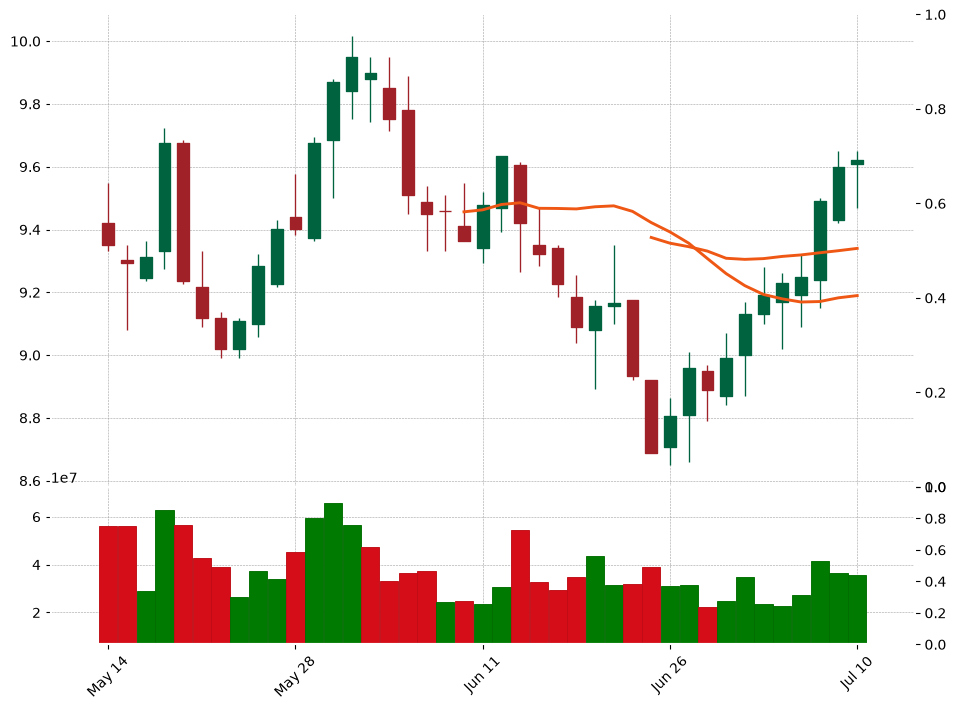

In [1]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
import talib
import mplfinance as mpf
import ffn
import matplotlib.pyplot as plt

# ==============================================
# ⚙️ SETTINGS
# ==============================================
TICKER = "600025.SS"
START_DATE = "2026-05-14"
END_DATE = "2026-07-13"
INITIAL_CAPITAL = 100000
TRANSACTION_FEE = 0.0003

# Strategy Rules
MIN_MA_GAP_PCT = 0.2
MIN_MA30_SLOPE = 0.004
RSI_BUY_THRESHOLD = 70
RSI_SELL_THRESHOLD = 30

# --- Risk Management Method ---
USE_METHOD = "SR"          # Choose: "SR" = Support/Resistance, "FIB" = Fibonacci
FIB_TARGET = 1.272         # Fib extension level for TP
SWING_LOOKBACK = 2         # Periods to confirm swing high/low

os.makedirs("data", exist_ok=True)

# ==============================================
# 📥 1. GET & PREPARE DATA
# ==============================================
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
df = df.droplevel("Ticker", axis=1).reset_index()
df = df.rename(columns={
    "Date": "trade_date", "Open": "open", "High": "high",
    "Low": "low", "Close": "close", "Volume": "vol"
})
df = df[["trade_date", "open", "high", "low", "close", "vol"]]
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# ==============================================
# 📊 2. CALCULATE INDICATORS + SWING LEVELS
# ==============================================
close = df["close"].values
df["MA20"] = talib.SMA(close, 20)
df["MA30"] = talib.SMA(close, 30)
df["RSI"] = talib.RSI(close, 14)
df["MA30_slope"] = talib.LINEARREG_SLOPE(df["MA30"], 3)
df["MA_gap_pct"] = (df["MA20"] - df["MA30"]) / df["MA30"] * 100

# --- Find Swing Highs & Lows ---
def find_swings(df, lookback=2):
    df["swing_high"] = np.nan
    df["swing_low"] = np.nan
    for i in range(lookback, len(df)-lookback):
        # Swing High
        if (df["high"].iloc[i] > df["high"].iloc[i-lookback:i]).all() and \
           (df["high"].iloc[i] > df["high"].iloc[i+1:i+lookback+1]).all():
            df.loc[i, "swing_high"] = df["high"].iloc[i]
        # Swing Low
        if (df["low"].iloc[i] < df["low"].iloc[i-lookback:i]).all() and \
           (df["low"].iloc[i] < df["low"].iloc[i+1:i+lookback+1]).all():
            df.loc[i, "swing_low"] = df["low"].iloc[i]
    return df

df = find_swings(df, SWING_LOOKBACK)

df["Buy_Signal"] = np.nan
df["Sell_Signal"] = np.nan

# ==============================================
# 🚦 3. BACKTEST WITH S/R or FIB SL/TP
# ==============================================
hold = False
pos = 0
cash = INITIAL_CAPITAL
entry_price = sl_price = tp_price = 0.0
capital_list = []
trade_log = []

for idx, row in df.iterrows():
    price = row["close"]
    high = row["high"]
    low = row["low"]
    ma20 = row["MA20"]
    ma30 = row["MA30"]
    rsi = row["RSI"]
    ma_gap = row["MA_gap_pct"]
    ma30_slope = row["MA30_slope"]
    date = row["trade_date"]

    if pd.isna([ma20, ma30, rsi, ma_gap, ma30_slope]).any():
        capital_list.append(cash + pos * price)
        continue

    # --------------------------
    # BUY CONDITION
    # --------------------------
    if (not hold
        and ma20 > ma30
        and ma_gap > MIN_MA_GAP_PCT
        and ma30_slope > MIN_MA30_SLOPE
        and rsi < RSI_BUY_THRESHOLD):

        max_shares = int(cash / (price * (1 + TRANSACTION_FEE)))
        pos = (max_shares // 100) * 100
        if pos > 0:
            entry_price = price

            # --- Calculate SL & TP ---
            if USE_METHOD == "SR":
                # Nearest swing low below entry = SL
                past_lows = df.loc[:idx, "swing_low"].dropna()
                sl_price = past_lows[past_lows < entry_price].iloc[-1] if not past_lows[past_lows < entry_price].empty else entry_price * 0.95
                # Nearest swing high above entry = TP
                past_highs = df.loc[:idx, "swing_high"].dropna()
                tp_price = past_highs[past_highs > entry_price].iloc[0] if not past_highs[past_highs > entry_price].empty else entry_price * 1.10

            elif USE_METHOD == "FIB":
                # Get recent swing low → swing high
                past_lows = df.loc[:idx, "swing_low"].dropna()
                past_highs = df.loc[:idx, "swing_high"].dropna()
                if not past_lows.empty and not past_highs.empty:
                    recent_low = past_lows.iloc[-1]
                    recent_high = past_highs[past_highs < entry_price].iloc[-1]
                    range_size = recent_high - recent_low
                    sl_price = recent_low * 0.995  # Just below swing low
                    tp_price = recent_high + range_size * (FIB_TARGET - 1)
                else:
                    sl_price = entry_price * 0.95
                    tp_price = entry_price * 1.10

            # Prevent SL/TP from being too close/far
            sl_price = min(sl_price, entry_price * 0.97)  # Max 3% if SR is too close
            tp_price = max(tp_price, entry_price * 1.05) # Min 5% target

            cost = pos * entry_price * (1 + TRANSACTION_FEE)
            cash -= cost
            hold = True
            df.loc[idx, "Buy_Signal"] = row["low"] * 0.98
            print(f"✅ BUY {date.date()} | Entry: {entry_price:.2f} | SL: {sl_price:.2f} | TP: {tp_price:.2f}")

    # --------------------------
    # SELL CONDITIONS
    # --------------------------
    elif hold:
        trend_exit = (ma20 < ma30 or ma30_slope < 0) and ma_gap < -MIN_MA_GAP_PCT and rsi > RSI_SELL_THRESHOLD
        stop_exit = low <= sl_price
        profit_exit = high >= tp_price

        if trend_exit or stop_exit or profit_exit:
            proceeds = pos * price * (1 - TRANSACTION_FEE)
            cash += proceeds
            df.loc[idx, "Sell_Signal"] = row["high"] * 1.02
            ret_pct = (price / entry_price) - 1

            if stop_exit:
                print(f"🛑 STOP {date.date()} | Exit: {price:.2f} | Loss: {ret_pct:.2%}")
            elif profit_exit:
                print(f"💰 TP {date.date()} | Exit: {price:.2f} | Profit: {ret_pct:.2%}")
            else:
                print(f"🔴 TREND EXIT {date.date()} | Exit: {price:.2f} | {ret_pct:.2%}")

            trade_log.append(f"{date.date()} | {entry_price:.2f} → {price:.2f} | {ret_pct:.2%}")
            pos = hold = 0
            entry_price = sl_price = tp_price = 0

    capital_list.append(cash + pos * price)

capital_series = pd.Series(capital_list, index=df["trade_date"])

# ==============================================
# 📈 PLOT & REPORT
# ==============================================
df_plot = df.set_index("trade_date").rename(columns={"open":"Open","high":"High","low":"Low","close":"Close","vol":"Volume"})

ap_buy = mpf.make_addplot(df_plot["Buy_Signal"], type="scatter", marker="^", color="limegreen", markersize=11)
ap_sell = mpf.make_addplot(df_plot["Sell_Signal"], type="scatter", marker="v", color="crimson", markersize=11)
ap_rsi = [
    mpf.make_addplot(df_plot["RSI"], panel=1, color="purple"),
    mpf.make_addplot([30]*len(df_plot), panel=1, color="green", linestyle="--"),
    mpf.make_addplot([70]*len(df_plot), panel=1, color="red", linestyle="--")
]

mpf.plot(
    df_plot, type="candle", style="charles",
    title=f"{TICKER} | MA20/MA30 + {USE_METHOD} SL/TP",
    mav=(20,30), volume=True, addplot=[ap_buy, ap_sell] + ap_rsi,
    panel_ratios=(3,1), figsize=(12,9)
)

print("\n" + "="*70)
print(f"📊 RESULTS | METHOD: {USE_METHOD}")
print("="*70)
print(f"Initial: {INITIAL_CAPITAL:,.2f}")
print(f"Final:   {capital_series.iloc[-1]:,.2f}")
print(f"Return:  {ffn.calc_total_return(capital_series):.2%}")
print(f"Max DD:  {ffn.calc_max_drawdown(capital_series):.2%}")
print(f"Sharpe:  {ffn.calc_sharpe(capital_series):.2f}")
print(f"Trades:  {len(trade_log)}")
bh = df["close"].iloc[-1]/df["close"].iloc[0]-1
print(f"Buy&Hold:{bh:.2%}")
print("="*70)